# 🇮🇳 India Economic Analysis (2000–2023)

Analyzing India's economic trajectory across 24 years using World Bank data.

**Key Questions:**
- How has India's GDP grown over 2 decades?
- What impact did COVID-19 have on the economy?
- How does unemployment relate to GDP growth?

**Tools:** Python, Pandas, Matplotlib, Seaborn  
**Data Source:** World Bank Open Data

In [1]:
import pandas as pd
df = pd.read_csv("data/india_economy_clean.csv")
print(df.columns.tolist())
print(df.head())
print(df.shape)

['Year', 'GDP_USD', 'GDP_Trillion_USD', 'Unemployment_Rate', 'Policy_Score', 'GDP_Growth_Rate', 'Economic_Era', 'GDP_Label']
   Year       GDP_USD  GDP_Trillion_USD  Unemployment_Rate  Policy_Score  \
0  2000  4.683955e+11             0.468               7.59           NaN   
1  2001  4.854401e+11             0.485               7.61           NaN   
2  2002  5.149391e+11             0.515               7.68           NaN   
3  2003  6.077007e+11             0.608               7.63           NaN   
4  2004  7.091527e+11             0.709               7.60           NaN   

   GDP_Growth_Rate Economic_Era GDP_Label  
0              NaN  Early 2000s    $0.47T  
1             3.64  Early 2000s    $0.48T  
2             6.08  Early 2000s    $0.52T  
3            18.01  Early 2000s    $0.61T  
4            16.69  Early 2000s    $0.71T  
(24, 8)


In [2]:
# ─────────────────────────────────────────
# CELL 1 — Imports & Load Data
# ─────────────────────────────────────────
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

# Style
sns.set_theme(style="darkgrid")
plt.rcParams["figure.dpi"] = 130
plt.rcParams["font.family"] = "DejaVu Sans"

df = pd.read_csv("data/india_economy_clean.csv")
df = df.dropna(subset=["GDP_Trillion_USD", "Unemployment_Rate"])

print(f"Years covered: {df['Year'].min()} – {df['Year'].max()}")
print(f"Peak GDP: {df.loc[df['GDP_Trillion_USD'].idxmax(), 'GDP_Label']} "
      f"in {df.loc[df['GDP_Trillion_USD'].idxmax(), 'Year']}")
print(f"Avg Unemployment: {df['Unemployment_Rate'].mean():.2f}%")


Years covered: 2000 – 2023
Peak GDP: $3.64T in 2023
Avg Unemployment: 7.27%


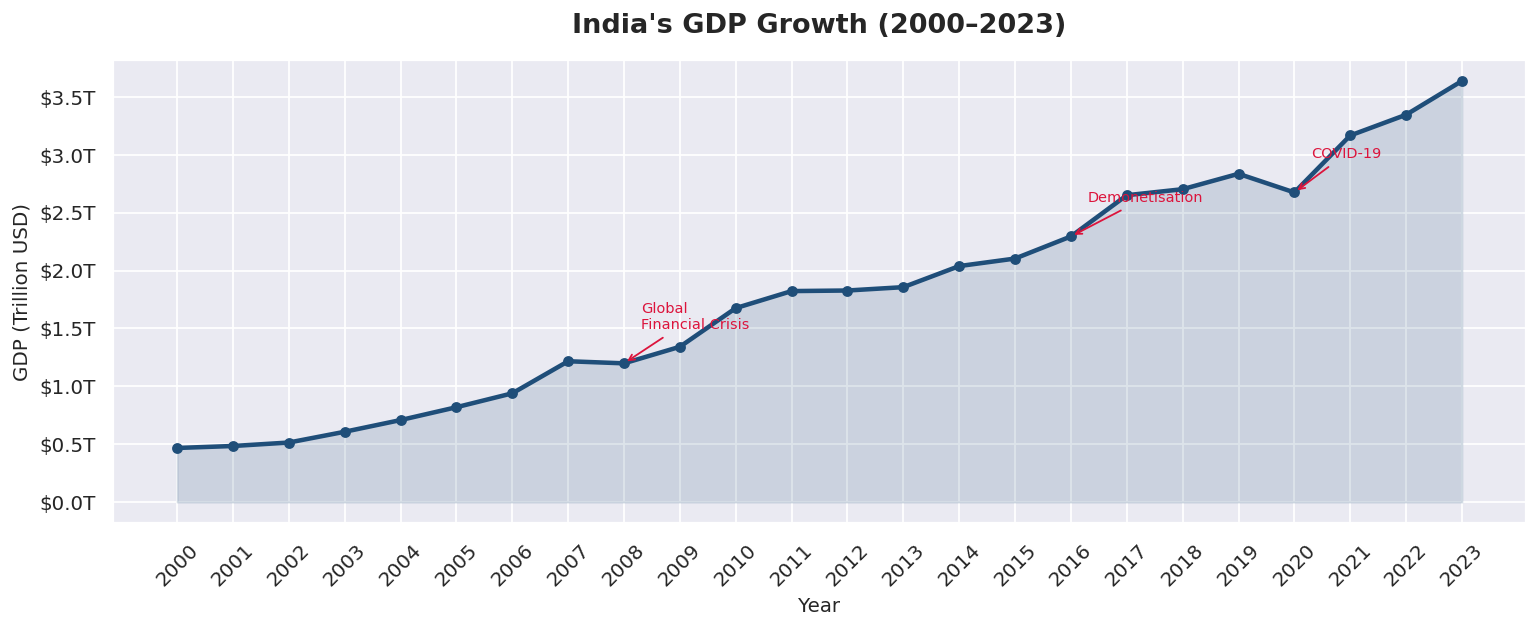

India's GDP grew from $0.47T in 2000 to over $3.3T by 2022 — a 7x increase in 22 years.


In [3]:
# ─────────────────────────────────────────
# CELL 2 — Chart 1: India GDP Growth (2000–2023)
# ─────────────────────────────────────────
fig, ax = plt.subplots(figsize=(12, 5))

ax.fill_between(df["Year"], df["GDP_Trillion_USD"], alpha=0.15, color="#1F4E79")
ax.plot(df["Year"], df["GDP_Trillion_USD"], color="#1F4E79", linewidth=2.5, marker="o", markersize=5)

# Annotate key milestones
milestones = {
    2008: "Global\nFinancial Crisis",
    2016: "Demonetisation",
    2020: "COVID-19"
}
for year, label in milestones.items():
    row = df[df["Year"] == year]
    if not row.empty:
        y_val = row["GDP_Trillion_USD"].values[0]
        ax.annotate(label, xy=(year, y_val),
                    xytext=(year + 0.3, y_val + 0.3),
                    fontsize=8, color="crimson",
                    arrowprops=dict(arrowstyle="->", color="crimson", lw=1))

ax.set_title("India's GDP Growth (2000–2023)", fontsize=15, fontweight="bold", pad=15)
ax.set_xlabel("Year", fontsize=11)
ax.set_ylabel("GDP (Trillion USD)", fontsize=11)
ax.yaxis.set_major_formatter(mticker.FormatStrFormatter("$%.1fT"))
ax.set_xticks(df["Year"])
ax.tick_params(axis="x", rotation=45)
plt.tight_layout()
plt.savefig("charts/01_gdp_growth.png", bbox_inches="tight")
plt.show()
print("India's GDP grew from $0.47T in 2000 to over $3.3T by 2022 — a 7x increase in 22 years.")


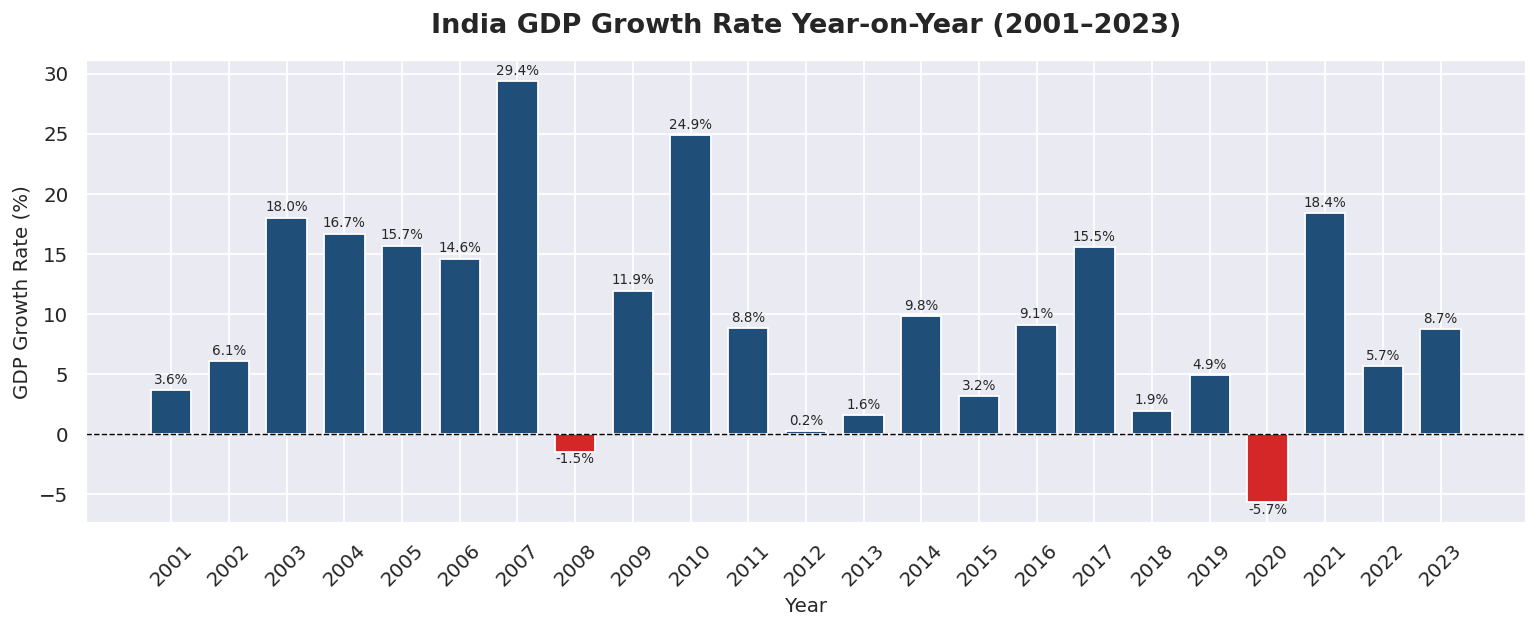

2020 saw a sharp GDP contraction due to COVID-19 — India's first negative growth in decades.


In [4]:
# ─────────────────────────────────────────
# CELL 3 — Chart 2: Year-on-Year GDP Growth Rate
# ─────────────────────────────────────────
df_growth = df.dropna(subset=["GDP_Growth_Rate"])

colors = ["#d62728" if x < 0 else "#1F4E79" for x in df_growth["GDP_Growth_Rate"]]

fig, ax = plt.subplots(figsize=(12, 5))
bars = ax.bar(df_growth["Year"], df_growth["GDP_Growth_Rate"], color=colors, edgecolor="white", width=0.7)

# Add value labels on bars
for bar, val in zip(bars, df_growth["GDP_Growth_Rate"]):
    ax.text(bar.get_x() + bar.get_width() / 2,
            bar.get_height() + (0.3 if val >= 0 else -1.2),
            f"{val:.1f}%", ha="center", va="bottom", fontsize=7.5)

ax.axhline(0, color="black", linewidth=0.8, linestyle="--")
ax.set_title("India GDP Growth Rate Year-on-Year (2001–2023)", fontsize=15, fontweight="bold", pad=15)
ax.set_xlabel("Year", fontsize=11)
ax.set_ylabel("GDP Growth Rate (%)", fontsize=11)
ax.set_xticks(df_growth["Year"])
ax.tick_params(axis="x", rotation=45)
plt.tight_layout()
plt.savefig("charts/02_gdp_growth_rate.png", bbox_inches="tight")
plt.show()
print("2020 saw a sharp GDP contraction due to COVID-19 — India's first negative growth in decades.")


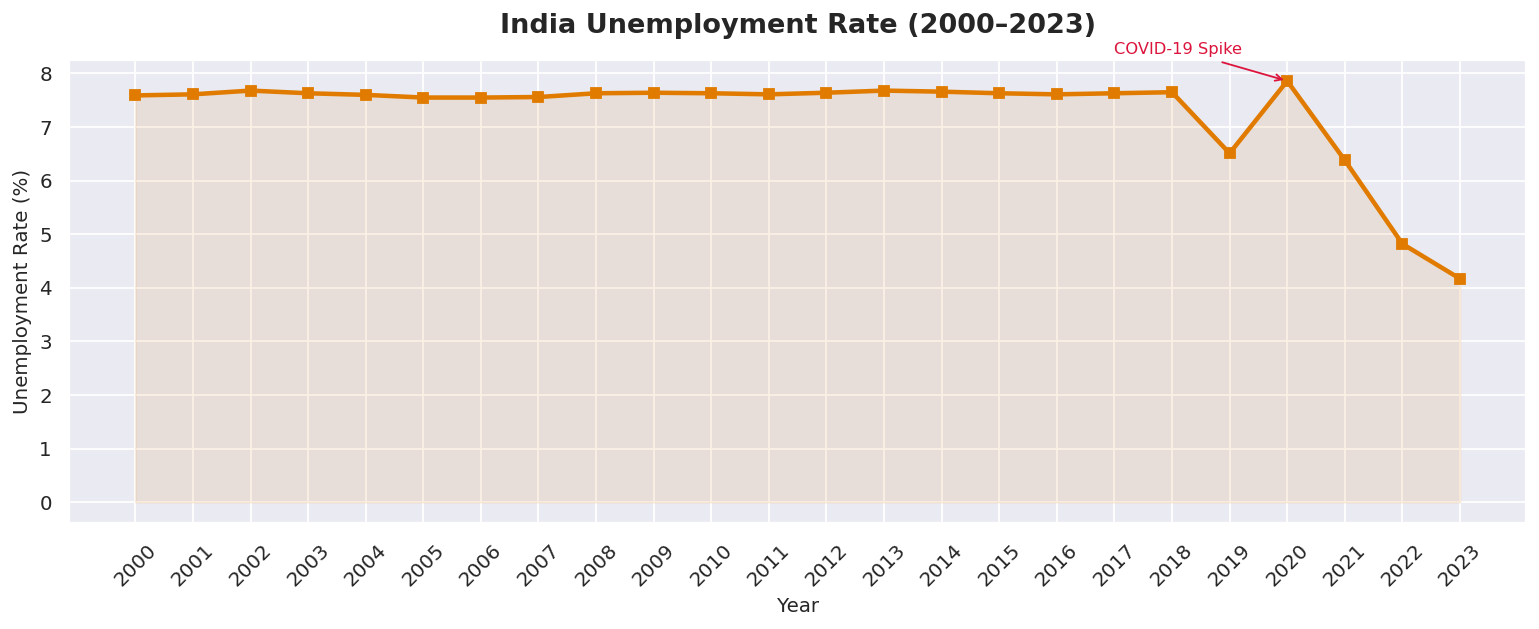

Unemployment spiked sharply in 2020 during COVID-19 lockdowns before recovering post-2021.


In [5]:
# ─────────────────────────────────────────
# CELL 4 — Chart 3: Unemployment Rate Trend
# ─────────────────────────────────────────
fig, ax = plt.subplots(figsize=(12, 5))

ax.plot(df["Year"], df["Unemployment_Rate"], color="#e07b00", linewidth=2.5, marker="s", markersize=5)
ax.fill_between(df["Year"], df["Unemployment_Rate"], alpha=0.1, color="#e07b00")

# Highlight COVID spike
covid_row = df[df["Year"] == 2020]
if not covid_row.empty:
    ax.annotate("COVID-19 Spike",
                xy=(2020, covid_row["Unemployment_Rate"].values[0]),
                xytext=(2017, covid_row["Unemployment_Rate"].values[0] + 0.5),
                fontsize=9, color="crimson",
                arrowprops=dict(arrowstyle="->", color="crimson"))

ax.set_title("India Unemployment Rate (2000–2023)", fontsize=15, fontweight="bold", pad=15)
ax.set_xlabel("Year", fontsize=11)
ax.set_ylabel("Unemployment Rate (%)", fontsize=11)
ax.set_xticks(df["Year"])
ax.tick_params(axis="x", rotation=45)
plt.tight_layout()
plt.savefig("charts/03_unemployment.png", bbox_inches="tight")
plt.show()
print("Unemployment spiked sharply in 2020 during COVID-19 lockdowns before recovering post-2021.")


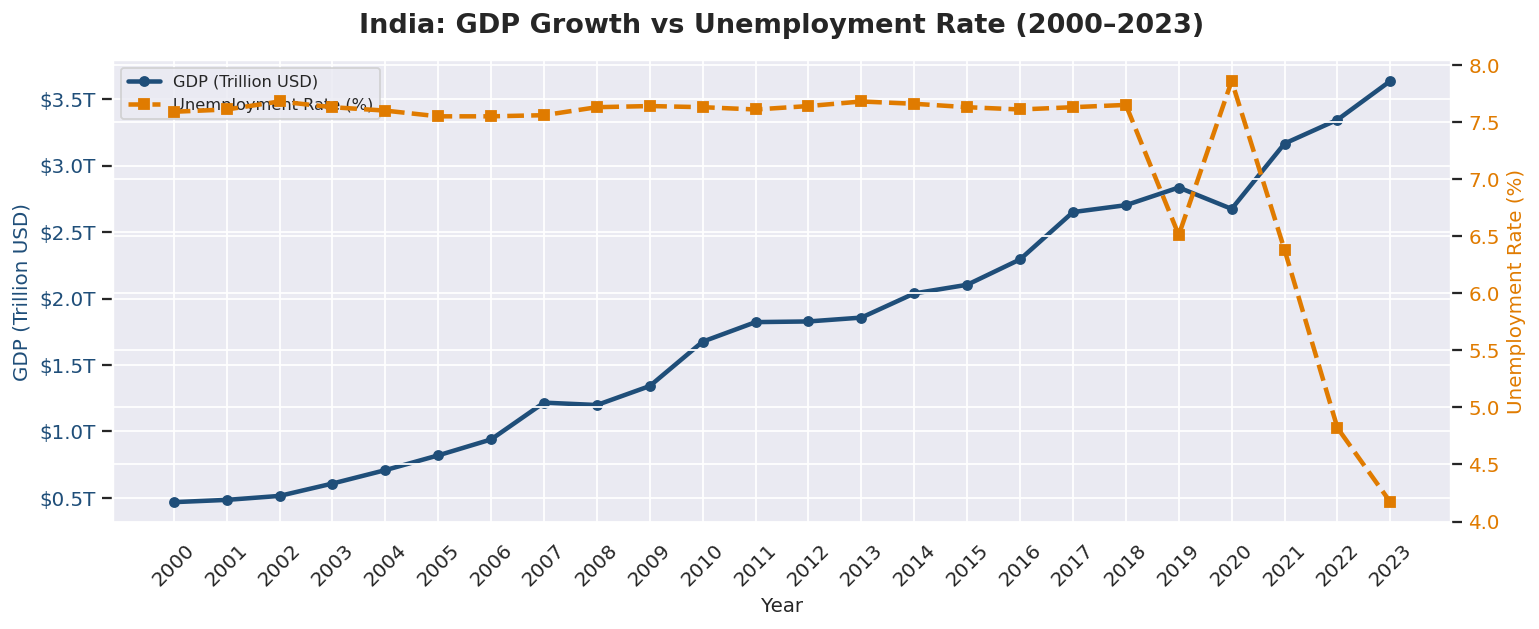

As GDP grew, unemployment remained relatively stable — suggesting growth was concentrated in capital-intensive sectors.


In [6]:
# ─────────────────────────────────────────
# CELL 5 — Chart 4: GDP vs Unemployment (Dual Axis)
# ─────────────────────────────────────────
fig, ax1 = plt.subplots(figsize=(12, 5))

ax1.plot(df["Year"], df["GDP_Trillion_USD"], color="#1F4E79", linewidth=2.5,
         marker="o", markersize=5, label="GDP (Trillion USD)")
ax1.set_ylabel("GDP (Trillion USD)", color="#1F4E79", fontsize=11)
ax1.tick_params(axis="y", labelcolor="#1F4E79")
ax1.yaxis.set_major_formatter(mticker.FormatStrFormatter("$%.1fT"))

ax2 = ax1.twinx()
ax2.plot(df["Year"], df["Unemployment_Rate"], color="#e07b00", linewidth=2.5,
         marker="s", markersize=5, linestyle="--", label="Unemployment Rate (%)")
ax2.set_ylabel("Unemployment Rate (%)", color="#e07b00", fontsize=11)
ax2.tick_params(axis="y", labelcolor="#e07b00")

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc="upper left", fontsize=9)

ax1.set_title("India: GDP Growth vs Unemployment Rate (2000–2023)",
              fontsize=15, fontweight="bold", pad=15)
ax1.set_xlabel("Year", fontsize=11)
ax1.set_xticks(df["Year"])
ax1.tick_params(axis="x", rotation=45)
plt.tight_layout()
plt.savefig("charts/04_gdp_vs_unemployment.png", bbox_inches="tight")
plt.show()
print("As GDP grew, unemployment remained relatively stable — suggesting growth was concentrated in capital-intensive sectors.")


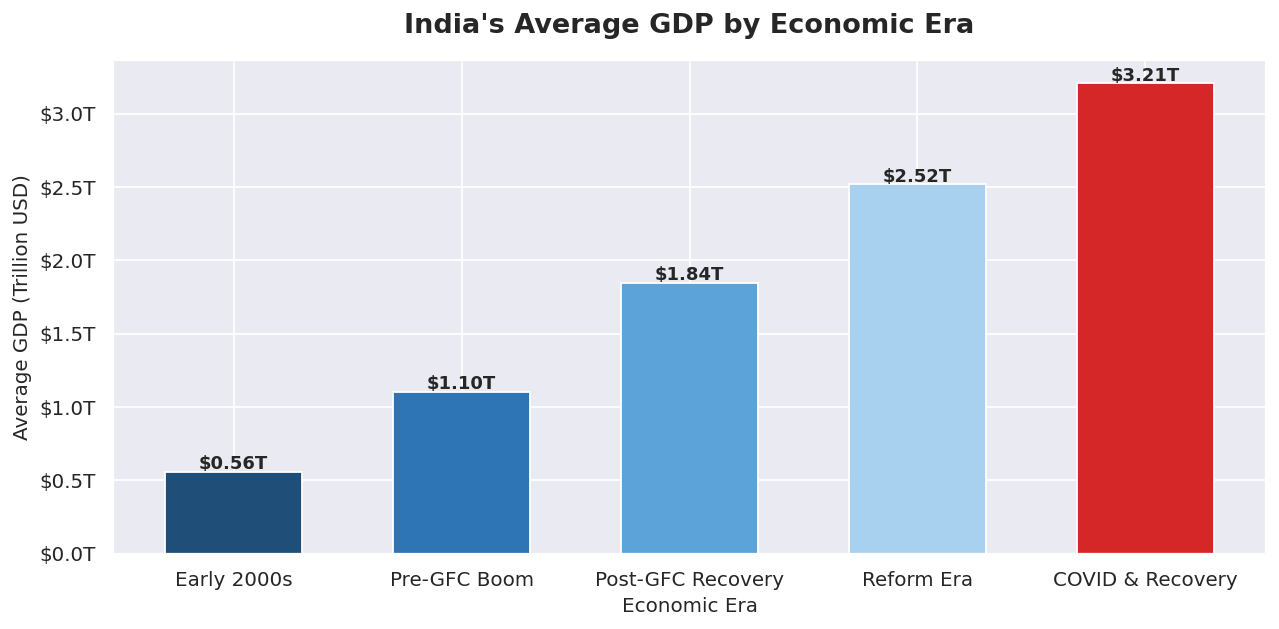

India's average GDP nearly tripled from the Reform Era to the COVID & Recovery period.


In [7]:
# ─────────────────────────────────────────
# CELL 6 — Chart 5: Average GDP by Economic Era
# ─────────────────────────────────────────
era_order = ["Early 2000s", "Pre-GFC Boom", "Post-GFC Recovery", "Reform Era", "COVID & Recovery"]
era_df = df.groupby("Economic_Era")["GDP_Trillion_USD"].mean().reindex(era_order).reset_index()

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.bar(era_df["Economic_Era"], era_df["GDP_Trillion_USD"],
              color=["#1F4E79", "#2E75B6", "#5BA3D9", "#A8D1F0", "#d62728"],
              edgecolor="white", width=0.6)

for bar, val in zip(bars, era_df["GDP_Trillion_USD"]):
    ax.text(bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.02,
            f"${val:.2f}T", ha="center", fontsize=10, fontweight="bold")

ax.set_title("India's Average GDP by Economic Era", fontsize=15, fontweight="bold", pad=15)
ax.set_xlabel("Economic Era", fontsize=11)
ax.set_ylabel("Average GDP (Trillion USD)", fontsize=11)
ax.yaxis.set_major_formatter(mticker.FormatStrFormatter("$%.1fT"))
plt.tight_layout()
plt.savefig("charts/05_gdp_by_era.png", bbox_inches="tight")
plt.show()
print("India's average GDP nearly tripled from the Reform Era to the COVID & Recovery period.")


In [8]:
# ─────────────────────────────────────────
# CELL 7 — Summary Stats (for README)
# ─────────────────────────────────────────
print("\n" + "="*50)
print("KEY FINDINGS SUMMARY")
print("="*50)
print(f"GDP in 2000:  {df[df['Year']==2000]['GDP_Label'].values[0]}")
print(f"GDP in 2022:  {df[df['Year']==2022]['GDP_Label'].values[0]}")
print(f"Peak growth year: {df.loc[df['GDP_Growth_Rate'].idxmax(), 'Year']} "
      f"at {df['GDP_Growth_Rate'].max():.1f}%")
print(f"Worst year (COVID): {df.loc[df['GDP_Growth_Rate'].idxmin(), 'Year']} "
      f"at {df['GDP_Growth_Rate'].min():.1f}%")
print(f"Avg unemployment: {df['Unemployment_Rate'].mean():.2f}%")
print(f"Peak unemployment: {df['Unemployment_Rate'].max():.2f}% "
      f"in {df.loc[df['Unemployment_Rate'].idxmax(), 'Year']}")



KEY FINDINGS SUMMARY
GDP in 2000:  $0.47T
GDP in 2022:  $3.35T
Peak growth year: 2007 at 29.4%
Worst year (COVID): 2020 at -5.7%
Avg unemployment: 7.27%
Peak unemployment: 7.86% in 2020
